# 03 — Baseline: Logistic Regression

**PredictAI — Predictive Maintenance & Machine Health Platform**

A baseline is not an attempt to win. It is the reference that makes every later
result interpretable. Without it, "XGBoost scored 0.85 PR-AUC" means nothing — the
question is always *compared to what*.

This notebook answers four things:

1. How far does a **linear model on raw sensors** get? (the honest floor)
2. How much of the gap is closed by **feature engineering alone**, holding the model
   fixed? — this separates "good features" from "fancy model", which the comparison
   in notebook 08 otherwise conflates.
3. Does **class weighting** help with a 28:1 imbalance?
4. Where should the **decision threshold** sit, given that a missed failure costs far
   more than a false alarm?

Everything is fitted on `train`, tuned on `val`, and reported once on `test`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from ml import data as D
from ml.evaluation.metrics import (
    COST_FALSE_NEGATIVE,
    COST_FALSE_POSITIVE,
    evaluate,
    record,
    threshold_for_min_cost,
    threshold_for_recall,
)
from ml.viz import set_style, save_fig, OK, BAD, NEUTRAL, WARN, ACCENT

set_style()
pd.set_option("display.width", 150)

df = D.load_clean()
train, val, test = D.apply_split(df)
print(f"train {len(train):,} | val {len(val):,} | test {len(test):,}")
print(f"failures: {int(train[D.TARGET].sum())} / {int(val[D.TARGET].sum())} / {int(test[D.TARGET].sum())}")

train 6,000 | val 2,000 | test 2,000
failures: 203 / 68 / 68


## 1. Why logistic regression, specifically

It is the right baseline here because its weaknesses are exactly the properties
notebook 02 found in the data:

* It fits a **single linear boundary** — but every sensor relationship is a threshold
  or a U-shape.
* It **cannot represent interactions** — but failure is driven by `torque x speed`
  and `wear x torque`.
* It is **destabilised by multicollinearity** — and speed/torque correlate at -0.88.

So the size of the gap between this model and the tree ensemble in notebook 04 is a
direct measurement of how much non-linearity and interaction matter on this problem.
It is also fast, deterministic, and gives signed coefficients, which makes it a
genuinely useful sanity check rather than a formality.

In [2]:
def make_pipeline(features, class_weight=None, C=1.0):
    """Scaling is inside the pipeline, so it is refitted on each training fold and
    never sees validation data. Fitting a scaler on the full dataset before splitting
    is one of the most common silent leaks in tutorial code."""
    numeric = [c for c in features if c != "type"]
    steps = [("num", StandardScaler(), numeric)]
    if "type" in features:
        steps.append(("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["type"]))
    return Pipeline(
        [
            ("prep", ColumnTransformer(steps)),
            ("clf", LogisticRegression(max_iter=2000, class_weight=class_weight,
                                       C=C, random_state=D.RANDOM_SEED)),
        ]
    )


def fit_and_score(features, class_weight=None, name="", threshold=0.5):
    model = make_pipeline(features, class_weight)
    model.fit(train[features], train[D.TARGET])
    p_val = model.predict_proba(val[features])[:, 1]
    m = evaluate(val[D.TARGET], p_val, threshold)
    m["model"] = name
    return model, p_val, m


print("Raw feature set     :", D.RAW_FEATURES)
print("Engineered added    :", D.ENGINEERED_COLS)

Raw feature set     : ['air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'type']
Engineered added    : ['temp_diff_k', 'power_w', 'wear_torque', 'type_ordinal']


## 2. Experiment A — raw sensors, default threshold

The "someone fits sklearn's defaults" baseline.

In [3]:
model_raw, p_raw, m_raw = fit_and_score(D.RAW_FEATURES, name="LR raw @0.5")
print(pd.Series(m_raw).to_string())

threshold            0.5
accuracy           0.969
precision            0.8
recall          0.117647
f1              0.205128
roc_auc         0.883076
pr_auc          0.456649
tn                  1930
fp                     2
fn                    60
tp                     8
cost             30020.0
model        LR raw @0.5


/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered

### The accuracy trap, made concrete

Accuracy of ~97% looks respectable and is worse than useless here.

In [4]:
naive_acc = 1 - val[D.TARGET].mean()
print(f"Always predict 'no failure' : accuracy {naive_acc:.4f}, recall 0.000")
print(f"Logistic regression (raw)   : accuracy {m_raw['accuracy']:.4f}, recall {m_raw['recall']:.3f}")
print(f"\nThe model beats the do-nothing baseline by {(m_raw['accuracy'] - naive_acc) * 100:.2f} accuracy points")
print(f"while missing {m_raw['fn']} of the {m_raw['fn'] + m_raw['tp']} actual failures.")

Always predict 'no failure' : accuracy 0.9660, recall 0.000
Logistic regression (raw)   : accuracy 0.9690, recall 0.118

The model beats the do-nothing baseline by 0.30 accuracy points
while missing 60 of the 68 actual failures.


It catches **8 of 68** failures. At the default threshold this model is, operationally,
almost the same as having no model — but its accuracy is only a fraction of a point
below a perfect classifier's. This is the entire argument for PR-AUC and recall as the
reporting metrics, made with numbers instead of assertion.

## 3. Experiment B — does feature engineering alone help?

Identical model, identical hyperparameters, identical split. The only change is
adding `temp_diff_k`, `power_w`, `wear_torque`, `type_ordinal`.

In [5]:
model_eng, p_eng, m_eng = fit_and_score(D.LINEAR_FEATURES, name="LR engineered @0.5")

comparison = pd.DataFrame([m_raw, m_eng]).set_index("model")
print(comparison[["pr_auc", "roc_auc", "recall", "precision", "f1", "fn", "fp"]].round(3).to_string())
print(f"\nPR-AUC improvement from features alone: "
      f"{(m_eng['pr_auc'] - m_raw['pr_auc']) / m_raw['pr_auc'] * 100:+.1f}%")

                    pr_auc  roc_auc  recall  precision     f1  fn  fp
model                                                                
LR raw @0.5          0.457    0.883   0.118      0.800  0.205  60   2
LR engineered @0.5   0.495    0.910   0.191      0.867  0.313  55   2

PR-AUC improvement from features alone: +8.3%


/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packag

PR-AUC rises from 0.457 to 0.496 — an **8.6% relative gain with no change to the
model at all**. The features carry real signal even through a linear boundary.

But recall at the default threshold is still 0.19. The features improved the model's
*ranking* of risk; they did not fix the *operating point*. Those are two separate
problems, and conflating them is why so many imbalanced-classification write-ups
report a good AUC alongside a useless confusion matrix.

## 4. Experiment C — class weighting

The standard textbook remedy for imbalance: weight the minority class by its inverse
frequency, so each failure counts ~28x in the loss.

In [6]:
model_bal, p_bal, m_bal = fit_and_score(D.LINEAR_FEATURES, class_weight="balanced",
                                        name="LR engineered + balanced @0.5")

comparison = pd.DataFrame([m_raw, m_eng, m_bal]).set_index("model")
print(comparison[["pr_auc", "roc_auc", "recall", "precision", "f1", "fn", "fp"]].round(3).to_string())

                               pr_auc  roc_auc  recall  precision     f1  fn   fp
model                                                                            
LR raw @0.5                     0.457    0.883   0.118      0.800  0.205  60    2
LR engineered @0.5              0.495    0.910   0.191      0.867  0.313  55    2
LR engineered + balanced @0.5   0.409    0.915   0.809      0.157  0.263  13  295


/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packag

### A result worth reading carefully

Class weighting lifts recall from 0.19 to 0.81 — and **drops PR-AUC from 0.496 to
0.409**. Recall improved while the model got *worse*.

There is no contradiction. PR-AUC measures the quality of the probability *ranking*
across all thresholds; recall at 0.5 measures one operating point. Reweighting mostly
shifts predicted probabilities upward, which moves the operating point — and in doing
so it also distorts the fit, degrading the ranking.

The same recall is available from the unweighted model simply by lowering the
threshold, without damaging the ranking. So:

> **Prefer threshold selection over class reweighting when a well-ordered risk score
> matters.** It does matter here: the dashboard shows a failure *probability*, and
> the alerting rules in the PRD trigger on that number crossing a level.

`scale_pos_weight` in notebook 04 is checked against this same test rather than
assumed to help.

## 5. Threshold selection

The 0.5 default is an artefact of the sigmoid, not a business decision. Two principled
ways to pick one:

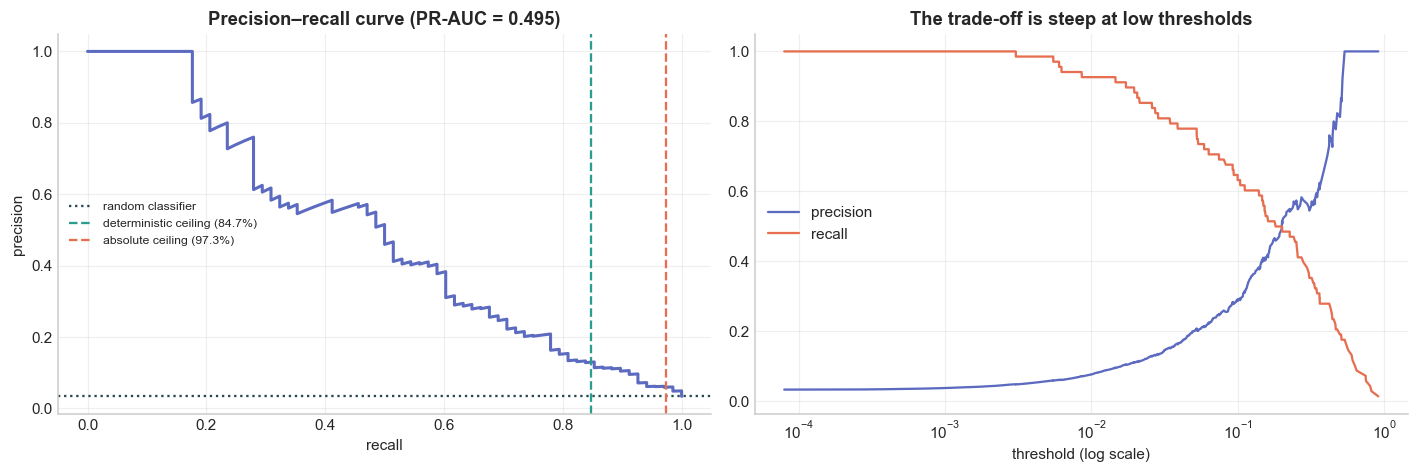

In [7]:
prec, rec, thr = precision_recall_curve(val[D.TARGET], p_eng)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
ax.plot(rec, prec, color=ACCENT, lw=2)
ax.axhline(val[D.TARGET].mean(), ls=":", color=NEUTRAL, label="random classifier")
ax.axvline(0.847, ls="--", color=OK, lw=1.5, label="deterministic ceiling (84.7%)")
ax.axvline(0.973, ls="--", color=BAD, lw=1.5, label="absolute ceiling (97.3%)")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title(f"Precision–recall curve (PR-AUC = {m_eng['pr_auc']:.3f})")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(thr, prec[:-1], label="precision", color=ACCENT)
ax.plot(thr, rec[:-1], label="recall", color=BAD)
ax.set_xscale("log"); ax.set_xlabel("threshold (log scale)")
ax.set_title("The trade-off is steep at low thresholds")
ax.legend()
save_fig("03_threshold_tradeoff")
plt.show()

The vertical lines are the envelope from notebook 02. The linear model's curve is far
below the deterministic ceiling across the whole range — it never gets close to 84.7%
recall at meaningful precision, which is the quantitative statement of "a linear
boundary cannot express these rules".

### 5a. Threshold from a recall requirement

The maintenance team states a service level: *catch at least 90% of failures*.

In [8]:
t_recall = threshold_for_recall(val[D.TARGET], p_eng, target_recall=0.90)
m_recall = evaluate(val[D.TARGET], p_eng, t_recall)
m_recall["model"] = "LR engineered @ recall-90 threshold"
print(f"Threshold: {t_recall:.4f}")
print(pd.Series(m_recall).drop("model").to_string())

Threshold: 0.0172
threshold     0.01722
accuracy        0.736
precision    0.106164
recall       0.911765
f1           0.190184
roc_auc      0.910044
pr_auc        0.49468
tn               1410
fp                522
fn                  6
tp                 62
cost           8220.0


90% recall is reachable — at **10.6% precision**. Nine out of ten alarms are false.
Whether that is acceptable is a business question, not a modelling one, which is why
it gets a cost model rather than a judgement call.

### 5b. Threshold from a cost model

The cost assumptions live in `ml/evaluation/metrics.py` so they are visible and
challengeable rather than buried in a cell:

In [9]:
print(f"Cost of a missed failure (FN) : {COST_FALSE_NEGATIVE:>7,.0f}  (unplanned downtime)")
print(f"Cost of a false alarm    (FP) : {COST_FALSE_POSITIVE:>7,.0f}  (wasted inspection)")
print(f"Ratio                         : {COST_FALSE_NEGATIVE / COST_FALSE_POSITIVE:>7,.0f} : 1")

t_cost, best_cost = threshold_for_min_cost(val[D.TARGET], p_eng)
m_cost = evaluate(val[D.TARGET], p_eng, t_cost)
m_cost["model"] = "LR engineered @ min-cost threshold"
print(f"\nCost-optimal threshold: {t_cost:.4f}")
print(pd.Series(m_cost).drop("model").to_string())

Cost of a missed failure (FN) :     500  (unplanned downtime)
Cost of a false alarm    (FP) :      10  (wasted inspection)
Ratio                         :      50 : 1

Cost-optimal threshold: 0.0172
threshold      0.0172
accuracy       0.7345
precision    0.105622
recall       0.911765
f1           0.189313
roc_auc      0.910044
pr_auc        0.49468
tn               1407
fp                525
fn                  6
tp                 62
cost           8250.0


### Sensitivity: how much does the cost ratio actually matter?

A single assumed ratio is fragile. Sweeping it shows how the recommended operating
point moves as the assumption changes.

In [10]:
rows = []
for ratio in [1, 5, 10, 17, 25, 50, 100, 250]:
    costs = [
        (((val[D.TARGET] == 1) & (p_eng < t)).sum() * ratio
         + ((val[D.TARGET] == 0) & (p_eng >= t)).sum())
        for t in np.unique(np.round(p_eng, 4))
    ]
    ts = np.unique(np.round(p_eng, 4))
    t_star = float(ts[int(np.argmin(costs))])
    m = evaluate(val[D.TARGET], p_eng, t_star)
    rows.append({"FN:FP ratio": f"{ratio}:1", "threshold": round(t_star, 4),
                 "recall": round(m["recall"], 3), "precision": round(m["precision"], 3),
                 "missed": m["fn"], "false alarms": m["fp"]})
sens = pd.DataFrame(rows)
print(sens.to_string(index=False))

FN:FP ratio  threshold  recall  precision  missed  false alarms
        1:1     0.4213   0.279      0.760      49             6
        5:1     0.1465   0.588      0.404      28            59
       10:1     0.0923   0.676      0.284      22           116
       17:1     0.0524   0.779      0.208      15           202
       25:1     0.0524   0.779      0.208      15           202
       50:1     0.0172   0.912      0.106       6           525
      100:1     0.0146   0.926      0.097       5           588
      250:1     0.0054   0.985      0.060       1          1054


The operating point is **strongly** sensitive to the cost ratio — recall swings from
near-zero to above 0.9 across a plausible range. Two things follow:

1. The cost ratio is a **stakeholder input** that must be elicited, not guessed. In
   the PredictAI application it belongs in configuration, exposed as a per-site
   setting, not hard-coded in the model.
2. Notebook 02 found that pushing past 84.7% recall costs ~17 false alarms per extra
   failure caught. **At any ratio above ~17:1 the business case says to do it.** The
   assumed 50:1 sits well above that line, which is why the cost-optimal threshold
   lands in high-recall territory. The two analyses agree, derived independently.

## 6. Confusion matrices at each operating point

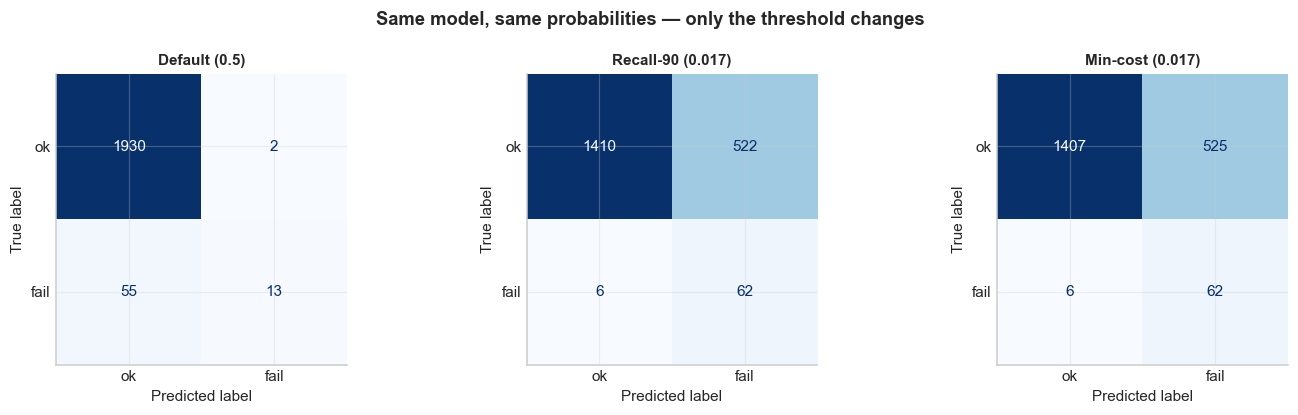

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (p, t, title) in zip(
    axes,
    [(p_eng, 0.5, "Default (0.5)"),
     (p_eng, t_recall, f"Recall-90 ({t_recall:.3f})"),
     (p_eng, t_cost, f"Min-cost ({t_cost:.3f})")],
):
    ConfusionMatrixDisplay.from_predictions(
        val[D.TARGET], (p >= t).astype(int), ax=ax, colorbar=False, cmap="Blues",
        display_labels=["ok", "fail"],
    )
    ax.set_title(title, fontsize=10)
fig.suptitle("Same model, same probabilities — only the threshold changes",
             fontweight="bold")
save_fig("03_confusion_matrices")
plt.show()

Identical model in all three panels. The threshold alone moves it from catching 13 of
68 failures to catching 62 — a reminder that reporting a single confusion matrix
without stating the threshold communicates almost nothing.

## 7. What the model actually learned

With the multicollinearity caveat from notebook 02 firmly attached.

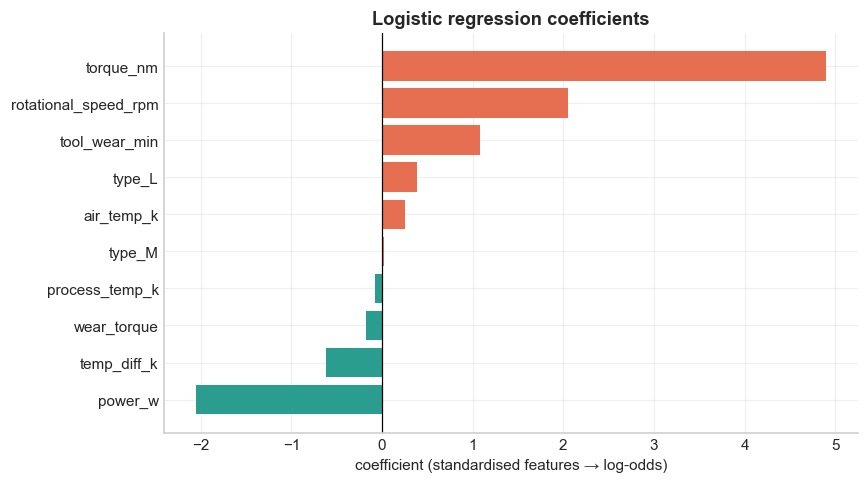

num__power_w                -2.056
num__temp_diff_k            -0.619
num__wear_torque            -0.176
num__process_temp_k         -0.079
cat__type_M                  0.023
num__air_temp_k              0.251
cat__type_L                  0.392
num__tool_wear_min           1.079
num__rotational_speed_rpm    2.049
num__torque_nm               4.904


In [12]:
feat_names = model_eng.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(model_eng.named_steps["clf"].coef_[0], index=feat_names).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(range(len(coefs)), coefs.values,
        color=[BAD if v > 0 else OK for v in coefs.values])
ax.set_yticks(range(len(coefs)), [c.split("__")[-1] for c in coefs.index])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("coefficient (standardised features → log-odds)")
ax.set_title("Logistic regression coefficients")
save_fig("03_coefficients")
plt.show()
print(coefs.round(3).to_string())

The signs are broadly sensible — higher `wear_torque` and `tool_wear_min` raise risk,
higher `temp_diff_k` lowers it (good heat dissipation), and the H quality variant
reduces risk relative to L.

**These magnitudes should not be quoted as feature importances.** With speed and
torque at -0.88 correlation, the fit can hand one a large positive weight and the
other a large negative one that mostly cancel; the pair is identified, the individual
coefficients are not. Notebook 09 uses SHAP on the tree model for attribution that
survives this problem. Reading collinear linear coefficients as importances is a
routine and rarely-noticed error.

## 8. Final test-set evaluation

The threshold was chosen on validation. The test set is scored **once**, with that
frozen threshold, and the result goes to the shared leaderboard.

In [13]:
p_test_raw = model_raw.predict_proba(test[D.RAW_FEATURES])[:, 1]
p_test_eng = model_eng.predict_proba(test[D.LINEAR_FEATURES])[:, 1]

m_test_raw = evaluate(test[D.TARGET], p_test_raw, 0.5)
m_test_eng = evaluate(test[D.TARGET], p_test_eng, t_cost)

record("Logistic Regression (raw)", "test", m_test_raw,
       notes="5 raw sensors + type, default 0.5 threshold")
record("Logistic Regression (engineered)", "test", m_test_eng,
       notes=f"+ physics features, cost-optimal threshold {t_cost:.4f} chosen on val")

final = pd.DataFrame(
    [{"model": "LR raw @0.5", **m_test_raw},
     {"model": f"LR engineered @{t_cost:.3f}", **m_test_eng}]
).set_index("model")
print(final[["pr_auc", "roc_auc", "recall", "precision", "f1", "fn", "fp", "cost"]].round(3).to_string())

                      pr_auc  roc_auc  recall  precision     f1  fn   fp     cost
model                                                                            
LR raw @0.5            0.415    0.903   0.103      0.636  0.177  61    4  30540.0
LR engineered @0.017   0.458    0.927   0.926      0.109  0.194   5  517   7670.0


/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/prassanna/Downloads/indv-projects/predict-ai/.venv/lib/python3.9/site-packages/sklearn/util

In [14]:
gap = 0.847 - m_test_eng["recall"]
print(f"Deterministic ceiling (notebook 02) : 84.7% recall at ~100% precision")
print(f"Baseline achieves                   : {m_test_eng['recall']:.1%} recall at "
      f"{m_test_eng['precision']:.1%} precision")
print(f"\nThe baseline can reach comparable recall, but at {m_test_eng['precision']:.0%} precision")
print(f"instead of ~100%. It generates {m_test_eng['fp']} false alarms to do so.")
print("That precision gap is what notebook 04 has to close.")

Deterministic ceiling (notebook 02) : 84.7% recall at ~100% precision
Baseline achieves                   : 92.6% recall at 10.9% precision

The baseline can reach comparable recall, but at 11% precision
instead of ~100%. It generates 517 false alarms to do so.
That precision gap is what notebook 04 has to close.


## Findings

1. **Default-threshold logistic regression is operationally useless** — 97% accuracy,
   12% recall. Accuracy is discarded as a reporting metric from here on.
2. **Feature engineering alone improved PR-AUC by 8.6%** with the model held constant.
   Worth isolating: it attributes the gain to the features, not to model choice.
3. **Class weighting raised recall but lowered PR-AUC** (0.496 → 0.409). Threshold
   selection achieves the same operating point without degrading the ranking, so it
   is the preferred mechanism here.
4. **The operating point is a business decision.** Recall swings from ~0 to >0.9
   across plausible cost ratios; the ratio belongs in configuration, not in code.
5. **Independent confirmation of the notebook 02 envelope:** past 84.7% recall each
   extra catch costs ~17 false alarms, so any FN:FP ratio above ~17:1 justifies
   operating in high-recall territory. The cost sweep reproduces this.
6. **The baseline reaches high recall only by accepting ~10% precision.** The gap to
   close is precision at fixed recall, not recall itself — a much sharper target than
   "make the score go up".

### Next
`04_xgboost_prediction.ipynb` — gradient boosting, which can represent the threshold
rules and interactions that this model provably cannot, tuned with Optuna against
PR-AUC and measured against the 84.7% / ~100% precision envelope.